## Failure Soon Classification

#### This notebook builds a classification model to predict whether an engine is approaching failure within a predefined RUL threshold.

#### The target variable will be:
#### - 1 → Failure Soon
#### - 0 → Not Failure Soon

#### The classification problem is derived from the RUL values created from the C-MAPSS FD001 training data.

In [1]:
import pandas as pd
import numpy as np

columns = (
    ["engine_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train = pd.read_csv(
    "CMAPSSData/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

# Calculate RUL
train["RUL"] = (
    train.groupby("engine_id")["cycle"]
    .transform("max") - train["cycle"]
)

train.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [2]:
# Create the classification target
failure_threshold = 30

train["failure_soon"] = (
    train["RUL"] <= failure_threshold
).astype(int)

train[["engine_id", "cycle", "RUL", "failure_soon"]].head(20)

,engine_id,cycle,RUL,failure_soon
0,1,1,191,0
1,1,2,190,0
2,1,3,189,0
3,1,4,188,0
4,1,5,187,0
5,1,6,186,0
6,1,7,185,0
7,1,8,184,0
8,1,9,183,0
9,1,10,182,0


## Class Distribution

#### Before training the classification model, we check the distribution of the two classes.
- 0 → Not Failure Soon
- 1 → Failure Soon

#### This is important because predictive-maintenance datasets can be imbalanced, with many more normal observations than failure-soon observations.

In [3]:
class_counts = train["failure_soon"].value_counts()

print(class_counts)
print()
print("Class percentage:")
print(train["failure_soon"].value_counts(normalize=True) * 100)

failure_soon
0    17531
1     3100
Name: count, dtype: int64

Class percentage:
failure_soon
0    84.974068
1    15.025932
Name: proportion, dtype: float64


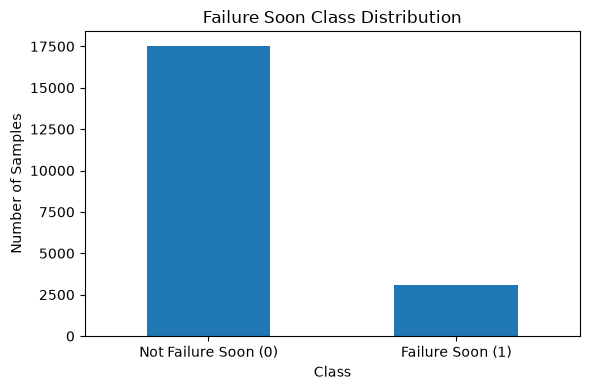

In [4]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

class_counts.plot(kind="bar")

plt.title("Failure Soon Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Failure Soon (0)", "Failure Soon (1)"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [5]:
# First remove constant sensors
constant_sensors = [
    "sensor_1",
    "sensor_5",
    "sensor_10",
    "sensor_16",
    "sensor_18",
    "sensor_19"
]

train_clean = train.drop(columns=constant_sensors)

print("Original shape:", train.shape)
print("After removing constant sensors:", train_clean.shape)

Original shape: (20631, 28)
After removing constant sensors: (20631, 22)


In [6]:
# Create the engineered sensors features
feature_sensors = [
    col for col in train_clean.columns
    if col.startswith("sensor_")
]

feature_data = train_clean.copy()

for sensor in feature_sensors:

    # Recent average sensor behaviour
    feature_data[f"{sensor}_rolling_mean"] = (
        feature_data.groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).mean()
        )
    )

    # Recent sensor variability
    feature_data[f"{sensor}_rolling_std"] = (
        feature_data.groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).std()
        )
    )

    # Change from previous cycle
    feature_data[f"{sensor}_delta"] = (
        feature_data.groupby("engine_id")[sensor].diff()
    )

feature_data.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_15_delta,sensor_17_rolling_mean,sensor_17_rolling_std,sensor_17_delta,sensor_20_rolling_mean,sensor_20_rolling_std,sensor_20_delta,sensor_21_rolling_mean,sensor_21_rolling_std,sensor_21_delta
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,NaN,392.000000,NaN,NaN,39.060000,NaN,NaN,23.419000,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,0.0123,392.000000,0.000000,0.0,39.030000,0.042426,-0.06,23.421300,0.003253,0.0046
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,-0.0140,391.333333,1.154701,-2.0,39.003333,0.055076,-0.05,23.395600,0.044573,-0.0794
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,-0.0496,391.500000,1.000000,2.0,38.972500,0.076322,-0.07,23.390175,0.037977,0.0297
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,0.0612,391.800000,1.095445,1.0,38.958000,0.073621,0.02,23.393020,0.033498,0.0305


In [24]:
# Prepare X and y
X = feature_data.drop(
    columns=["engine_id", "RUL", "failure_soon"]
)

y = feature_data["failure_soon"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20631, 64)
y shape: (20631,)


## Engine-wise Train-Validation Split

#### The data is split by engine_id so that the validation set contains engines that were not used during model training.

#### This prevents information from the same engine appearing in both training and validation data.

In [25]:
from sklearn.model_selection import train_test_split

engine_ids = feature_data["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = feature_data[
    feature_data["engine_id"].isin(train_engines)
].copy()

val_data = feature_data[
    feature_data["engine_id"].isin(val_engines)
].copy()

print("Training engines:", len(train_engines))
print("Validation engines:", len(val_engines))

print("Training shape:", train_data.shape)
print("Validation shape:", val_data.shape)

Training engines: 80
Validation engines: 20
Training shape: (16561, 67)
Validation shape: (4070, 67)


In [26]:
# Create X and y from these splits
X_train = train_data.drop(
    columns=["engine_id", "RUL", "failure_soon"]
)

y_train = train_data["failure_soon"]

X_val = val_data.drop(
    columns=["engine_id", "RUL", "failure_soon"]
)

y_val = val_data["failure_soon"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (16561, 64)
y_train: (16561,)
X_val: (4070, 64)
y_val: (4070,)


#### Check class imbalance separately in train and validation

In [27]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training class distribution:
failure_soon
0    14081
1     2480
Name: count, dtype: int64

Validation class distribution:
failure_soon
0    3450
1     620
Name: count, dtype: int64


In [28]:
print("Training percentages:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation percentages:")
print(y_val.value_counts(normalize=True) * 100)

Training percentages:
failure_soon
0    85.025059
1    14.974941
Name: proportion, dtype: float64

Validation percentages:
failure_soon
0    84.766585
1    15.233415
Name: proportion, dtype: float64


In [29]:
print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in X_val:", X_val.isnull().sum().sum())

NaN values in X_train: 2400
NaN values in X_val: 600


In [33]:
import numpy as np

print("NaN in X_train_imputed:", np.isnan(X_train_imputed).sum())
print("NaN in X_val_imputed:", np.isnan(X_val_imputed).sum())

NaN in X_train_imputed: 0
NaN in X_val_imputed: 0


In [34]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

print("Training shape:", X_train_imputed.shape)
print("Validation shape:", X_val_imputed.shape)

Training shape: (16561, 64)
Validation shape: (4070, 64)


## Handling Class Imbalance

#### The target variable is imbalanced, with approximately 85% of observations belonging to the normal class and 15% belonging to the failure-soon class.

#### We use class-weight balancing so that the classifier gives greater importance to the minority failure-soon class.

In [38]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

clf.fit(X_train_imputed, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


C:\Users\avnis\anaconda3_newml\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
y_pred_lr = clf.predict(X_val_imputed)

print("First 20 actual values:")
print(y_val.values[:20])

print("\nFirst 20 predicted values:")
print(y_pred_lr[:20])

First 20 actual values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 predicted values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [40]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val, y_pred_lr)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_lr))

Confusion Matrix:
[[3191  259]
 [  25  595]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      3450
           1       0.70      0.96      0.81       620

    accuracy                           0.93      4070
   macro avg       0.84      0.94      0.88      4070
weighted avg       0.95      0.93      0.93      4070



In [41]:
# Get failure probablities
y_prob_lr = clf.predict_proba(X_val_imputed)[:, 1]

print("First 20 failure probabilities:")
print(y_prob_lr[:20])

First 20 failure probabilities:
[2.07658164e-04 3.28396993e-04 1.78562601e-04 3.79762613e-05
 2.10791842e-04 6.64357462e-05 3.71776376e-05 8.17641226e-05
 2.38941886e-04 2.52753201e-04 3.73661470e-04 8.17522685e-05
 4.70267508e-04 3.49560790e-04 2.42022555e-04 1.97097523e-04
 3.42297861e-04 1.86091561e-04 1.18405553e-04 1.31374708e-04]


In [42]:
# Test different threshold
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_lr >= threshold).astype(int)
    
    precision = precision_score(y_val, y_pred_threshold)
    recall = recall_score(y_val, y_pred_threshold)
    f1 = f1_score(y_val, y_pred_threshold)
    
    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_results

,Threshold,Precision,Recall,F1
0,0.10,0.471483,1.000000,0.640827
1,0.15,0.516291,0.996774,0.680242
2,0.20,0.555356,0.995161,0.712883
3,0.25,0.587060,0.995161,0.738480
4,0.30,0.610558,0.988710,0.754926
5,0.35,0.639413,0.983871,0.775095
6,0.40,0.660460,0.972581,0.786693
7,0.45,0.678369,0.966129,0.797073
8,0.50,0.696721,0.959677,0.807327
9,0.55,0.721951,0.954839,0.822222


In [43]:
# Cost-sensitive threshold optimization

from sklearn.metrics import confusion_matrix
import pandas as pd

# Define costs
# False Negative (missed failure) is more expensive
cost_fp = 1
cost_fn = 5

cost_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_lr >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred_threshold
    ).ravel()

    total_cost = (fp * cost_fp) + (fn * cost_fn)

    cost_results.append({
        "threshold": threshold,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "total_cost": total_cost
    })

cost_df = pd.DataFrame(cost_results)

cost_df

,threshold,FP,FN,TP,TN,total_cost
0,0.10,695,0,620,2755,695
1,0.15,579,2,618,2871,589
2,0.20,494,3,617,2956,509
3,0.25,434,3,617,3016,449
4,0.30,391,7,613,3059,426
5,0.35,344,10,610,3106,394
6,0.40,310,17,603,3140,395
7,0.45,284,21,599,3166,389
8,0.50,259,25,595,3191,384
9,0.55,228,28,592,3222,368


In [44]:
best_threshold = cost_df.loc[
    cost_df["total_cost"].idxmin(),
    "threshold"
]

min_cost = cost_df["total_cost"].min()

print("Best cost-sensitive threshold:", best_threshold)
print("Minimum total cost:", min_cost)

Best cost-sensitive threshold: 0.6000000000000002
Minimum total cost: 361


In [45]:
# Final validation predictions using the selected threshold

y_pred_final = (y_prob_lr >= best_threshold).astype(int)

print("Selected threshold:", best_threshold)

Selected threshold: 0.6000000000000002


In [46]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val, y_pred_final)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_final))

Confusion Matrix:
[[3249  201]
 [  32  588]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.97      3450
           1       0.75      0.95      0.83       620

    accuracy                           0.94      4070
   macro avg       0.87      0.95      0.90      4070
weighted avg       0.95      0.94      0.95      4070

